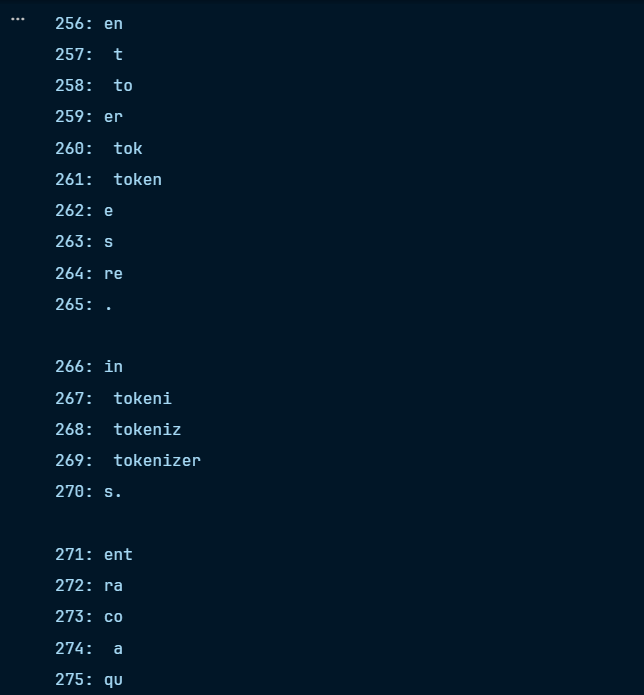

In [18]:
text = """
雪，我爱你💕
Large language models are trained to predict the next token.
A tokenizer converts raw text into a sequence of integers.
Byte pair encoding repeatedly merges frequent adjacent pairs.

测试 UTF-8 和 BPE 
Transformers process sequences of token representations.
Attention allows tokens to communicate with other tokens.
🚀 GPT GPT GPT tokenizer tokenizer tokenizer!
"""*2
tokens=text.encode("utf-8")
tokens=list(map(int,tokens))

tokens_2=list(text.encode("utf-8"))

print(tokens==tokens_2)

#print("text:",text)
print("text length:", len(text))
print("tokens:", tokens)
print("tokens length:", len(tokens))


True
text length: 734
tokens: [10, 233, 155, 170, 239, 188, 140, 230, 136, 145, 231, 136, 177, 228, 189, 160, 240, 159, 146, 149, 10, 76, 97, 114, 103, 101, 32, 108, 97, 110, 103, 117, 97, 103, 101, 32, 109, 111, 100, 101, 108, 115, 32, 97, 114, 101, 32, 116, 114, 97, 105, 110, 101, 100, 32, 116, 111, 32, 112, 114, 101, 100, 105, 99, 116, 32, 116, 104, 101, 32, 110, 101, 120, 116, 32, 116, 111, 107, 101, 110, 46, 10, 65, 32, 116, 111, 107, 101, 110, 105, 122, 101, 114, 32, 99, 111, 110, 118, 101, 114, 116, 115, 32, 114, 97, 119, 32, 116, 101, 120, 116, 32, 105, 110, 116, 111, 32, 97, 32, 115, 101, 113, 117, 101, 110, 99, 101, 32, 111, 102, 32, 105, 110, 116, 101, 103, 101, 114, 115, 46, 10, 66, 121, 116, 101, 32, 112, 97, 105, 114, 32, 101, 110, 99, 111, 100, 105, 110, 103, 32, 114, 101, 112, 101, 97, 116, 101, 100, 108, 121, 32, 109, 101, 114, 103, 101, 115, 32, 102, 114, 101, 113, 117, 101, 110, 116, 32, 97, 100, 106, 97, 99, 101, 110, 116, 32, 112, 97, 105, 114, 115, 46, 10, 10, 230

In [5]:
list("abcdefg".encode("utf-8"))

[97, 98, 99, 100, 101, 102, 103]

In [6]:
list("雪，我爱你💕".encode("utf-16"))

[255, 254, 234, 150, 12, 255, 17, 98, 49, 114, 96, 79, 61, 216, 149, 220]

In [7]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    return counts

stats=get_stats(tokens)
#print("stats:", stats)
print(sorted(((v,k)for k,v in stats.items()), reverse=True))

[(30, (101, 110)), (26, (32, 116)), (22, (116, 111)), (18, (101, 114)), (16, (115, 32)), (16, (111, 107)), (16, (107, 101)), (14, (101, 32)), (12, (116, 101)), (12, (114, 101)), (12, (110, 116)), (10, (116, 32)), (10, (114, 32)), (10, (110, 105)), (10, (46, 10)), (8, (122, 101)), (8, (115, 46)), (8, (110, 115)), (8, (105, 122)), (8, (105, 110)), (8, (103, 101)), (8, (101, 115)), (8, (99, 101)), (8, (32, 112)), (8, (32, 97)), (6, (117, 101)), (6, (116, 104)), (6, (115, 101)), (6, (114, 115)), (6, (114, 97)), (6, (113, 117)), (6, (112, 114)), (6, (111, 110)), (6, (111, 32)), (6, (110, 99)), (6, (101, 113)), (6, (101, 100)), (6, (99, 111)), (6, (97, 116)), (6, (97, 105)), (6, (84, 32)), (6, (80, 84)), (6, (71, 80)), (6, (32, 114)), (6, (32, 111)), (6, (32, 71)), (4, (240, 159)), (4, (120, 116)), (4, (116, 105)), (4, (114, 103)), (4, (112, 97)), (4, (111, 102)), (4, (111, 100)), (4, (110, 103)), (4, (110, 101)), (4, (110, 32)), (4, (109, 101)), (4, (105, 114)), (4, (105, 111)), (4, (105, 9

In [8]:
top_pair=max(stats, key=stats.get )
top_pair

(101, 110)

In [9]:
def merge(ids,pair,idx):
    newidx=[]
    i=0
    while i<len(ids):
        if i<len(ids)-1 and ids[i]==pair[0] and ids[i+1]==pair[1]:
            newidx.append(idx)
            i+=2
        else:
            newidx.append(ids[i])
            i+=1
    return newidx

print(merge([5,6,7,5,6,8],(5,6),100))


[100, 7, 100, 8]


In [10]:
tokens2=merge(tokens,top_pair,256)
print(tokens2)
print("tokens2 length:", len(tokens2))

[10, 233, 155, 170, 239, 188, 140, 230, 136, 145, 231, 136, 177, 228, 189, 160, 240, 159, 146, 149, 10, 76, 97, 114, 103, 101, 32, 108, 97, 110, 103, 117, 97, 103, 101, 32, 109, 111, 100, 101, 108, 115, 32, 97, 114, 101, 32, 116, 114, 97, 105, 110, 101, 100, 32, 116, 111, 32, 112, 114, 101, 100, 105, 99, 116, 32, 116, 104, 101, 32, 110, 101, 120, 116, 32, 116, 111, 107, 256, 46, 10, 65, 32, 116, 111, 107, 256, 105, 122, 101, 114, 32, 99, 111, 110, 118, 101, 114, 116, 115, 32, 114, 97, 119, 32, 116, 101, 120, 116, 32, 105, 110, 116, 111, 32, 97, 32, 115, 101, 113, 117, 256, 99, 101, 32, 111, 102, 32, 105, 110, 116, 101, 103, 101, 114, 115, 46, 10, 66, 121, 116, 101, 32, 112, 97, 105, 114, 32, 256, 99, 111, 100, 105, 110, 103, 32, 114, 101, 112, 101, 97, 116, 101, 100, 108, 121, 32, 109, 101, 114, 103, 101, 115, 32, 102, 114, 101, 113, 117, 256, 116, 32, 97, 100, 106, 97, 99, 256, 116, 32, 112, 97, 105, 114, 115, 46, 10, 10, 230, 181, 139, 232, 175, 149, 32, 85, 84, 70, 45, 56, 32, 229, 

In [11]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    return counts

def merge(ids,pair,idx):
    newidx=[]
    i=0
    while i<len(ids):
        if i<len(ids)-1 and ids[i]==pair[0] and ids[i+1]==pair[1]:
            newidx.append(idx)
            i+=2
        else:
            newidx.append(ids[i])
            i+=1
    return newidx

vocab_size=276
num_merges=vocab_size-256
ids=list(tokens)

merges={}#(int,int)->int
for i in range(num_merges):
    stats=get_stats(ids)
    top_pair=max(stats,key=stats.get)
    idx=256+i
    print(f"merging{top_pair}into a new token{idx}")
    ids=merge(ids,top_pair,idx)
    merges[top_pair]=idx
    



merging(101, 110)into a new token256
merging(32, 116)into a new token257
merging(257, 111)into a new token258
merging(101, 114)into a new token259
merging(258, 107)into a new token260
merging(260, 256)into a new token261
merging(101, 32)into a new token262
merging(115, 32)into a new token263
merging(114, 101)into a new token264
merging(46, 10)into a new token265
merging(105, 110)into a new token266
merging(261, 105)into a new token267
merging(267, 122)into a new token268
merging(268, 259)into a new token269
merging(115, 265)into a new token270
merging(256, 116)into a new token271
merging(114, 97)into a new token272
merging(99, 111)into a new token273
merging(32, 97)into a new token274
merging(113, 117)into a new token275


In [22]:
print("tokens before merge:", len(tokens))
print("tokens after merge:", len(ids))
print(f"compression ratio: {len(tokens)/len(ids):.2f}")

tokens before merge: 778
tokens after merge: 534
compression ratio: 1.46


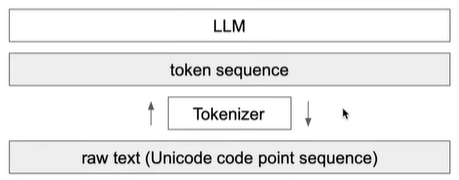

In [16]:
vocab={idx:bytes([idx])for idx in range (256)}
for (p0,p1),idx in merges.items():
    vocab[idx]=vocab[p0]+vocab[p1]

def decode(ids):
    tokens =b"".join(vocab[idx] for idx in ids)
    text=tokens.decode("utf-8",errors="replace")
    return text
print("decoded text:", decode([255,256]),
      decode([255]),decode([128])
      ,decode([88]),decode([256]),decode([257]),decode([258]),decode([259]),decode([260]),decode([261]),decode([262]),decode([263]),decode([264]),decode([265]),decode([266]),decode([267]),decode([268]),decode([269]),decode([270]),decode([271]),decode([272]),decode([273]),decode([274]),decode([275]))


decoded text: �en � � X en  t  to er  tok  token e  s  re .
 in  tokeni  tokeniz  tokenizer s.
 ent ra co  a qu


In [17]:
for i in range(256, vocab_size):
    print(f"{i}: {decode([i])}")

256: en
257:  t
258:  to
259: er
260:  tok
261:  token
262: e 
263: s 
264: re
265: .

266: in
267:  tokeni
268:  tokeniz
269:  tokenizer
270: s.

271: ent
272: ra
273: co
274:  a
275: qu


In [ ]:
def encode(text):
    tokens=list(text.encode("utf-8"))
    while len(tokens)>=2:
        stats=get_stats(tokens)
        pair=min(stats,key=lambda p:merges.get(p,float("inf")))#正无穷
        if pair not in merges:
            break
        idx=merges[pair]
        tokens=merge(tokens,pair,idx)#将所有的pair替换为拓展后的idx
    return tokens
print(encode(""))

[]


In [14]:
print(decode(encode("雪，我爱你💕")))

雪，我爱你💕


In [15]:
valtext="The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best "
valtext2=decode(encode(valtext))
print(valtext==valtext2)

True


forced splits using regex patterns(GPT)

In [ ]:
%pip install regex tiktoken

In [21]:
import regex as re
gpt2pat=re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")
print(gpt2pat.findall("The dominant123 sequence%% ?  ||  and a       decoder. The best "))

['The', ' dominant', '123', ' sequence', '%%', ' ?', ' ', ' ||', ' ', ' and', ' a', '      ', ' decoder', '.', ' The', ' best', ' ']


In [24]:
import tiktoken
#GPT 2
enc=tiktoken.get_encoding("gpt2")
print(enc.encode("    雪，我爱你！！！❤️"))
print(enc.encode("雪，我爱你！！！❤️"))
#GPT 4
enc=tiktoken.get_encoding("cl100k_base")
print(enc.encode("    雪，我爱你！！！❤️"))
print(enc.encode("                    雪，我爱你！！！❤️"))

[220, 220, 220, 16268, 249, 103, 171, 120, 234, 22755, 239, 163, 230, 109, 19526, 254, 171, 120, 223, 171, 120, 223, 171, 120, 223, 32391, 97, 37929]
[37239, 103, 171, 120, 234, 22755, 239, 163, 230, 109, 19526, 254, 171, 120, 223, 171, 120, 223, 171, 120, 223, 32391, 97, 37929]
[262, 18630, 249, 103, 3922, 37046, 76207, 109, 57668, 32351, 6447, 49633, 97, 31643]
[504, 18630, 249, 103, 3922, 37046, 76207, 109, 57668, 32351, 6447, 49633, 97, 31643]


In [1]:
import os,json
!wget https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/vocab.bpe
!wget https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/encoder.json


'wget' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���
'wget' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


In [ ]:
with open("encoder.json","r",encoding="utf-8") as f:
    encoder=json.load(f)

with open("vocab.bpe","r",encoding="utf-8") as f:
    bpe_data=f.read()   
bpe_merges=[tuple(merge_str.split()) for merge_str in bpe_data.split("\n")[1:-1]]

In [ ]:
%pip install sentencepiece

In [5]:
import sentencepiece as spm
with open("toy.txt","w",encoding="utf-8") as f:
    f.write("David Tao was born on July 11, 1969, in Hong Kong, to parents who were entertainers in Taiwan. His father, Tao Dawei (David Tao Sr.; September 28, 1942 – September 12, 2012),[2] was an actor, singer, composer, and TV host; his mother, Wang Furong (Catherine), is a Chinese opera singer.[citation needed]Tao spent part of his childhood in Hong Kong. He was educated in Taiwan from kindergarten through junior high at the Bethany Campus of Morrison Academy in Taipei. His family relocated to Arcadia, California, while his father pursued a career with Disney.[3] Tao attended Arcadia High School.[4]Tao's parents later returned to Taiwan, where his father began his singing career, leaving him to complete his education in the United States. Left to fend for himself, Tao took on many jobs, including a stint as a civilian employee at the Los Angeles Police Department without the knowledge of his parents.[clarification needed] He attended the University of California, Irvine, first. He graduated with a Bachelor of Arts in psychology from the University of California, Los Angeles.[citation needed]  In July 2015, Tao held a press conference in Taipei addressing reports about his private life and acknowledged he had dated Chinese artist manager Yang Ziqing prior to his marriage, a story that received wide media coverage at the time.[5][6]  In 2024, Tao returned to large-scale concert touring with the Soul Power II tour, announcing and staging dates across Taiwan and the surrounding region, including shows in Taipei, Kaohsiung, and Macau")

In [ ]:
import os
option=dist(
    input="toy.txt",
    input_format="text"
)